In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
image2 = cv2.imread('img.jpg')
image2_gray = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY) 

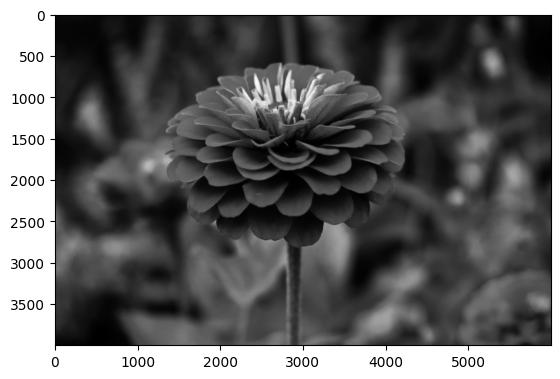

In [3]:
plt.imshow(image2_gray, cmap="gray")

In [4]:
# Gaussian noise
mean = 0
stddev = 150
noise_gauss = np.zeros(image2_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

array([[  0,  24,   0, ..., 224,  84,   0],
       [129,   0, 255, ...,   0,   0,  54],
       [ 59, 159,   0, ...,   0, 255,   0],
       ...,
       [  0,   0,  53, ...,   0,  53, 208],
       [  0,   0,   0, ...,   0, 160,   0],
       [153,   0,   0, ...,   0, 100,   0]],
      shape=(4000, 6000), dtype=uint8)

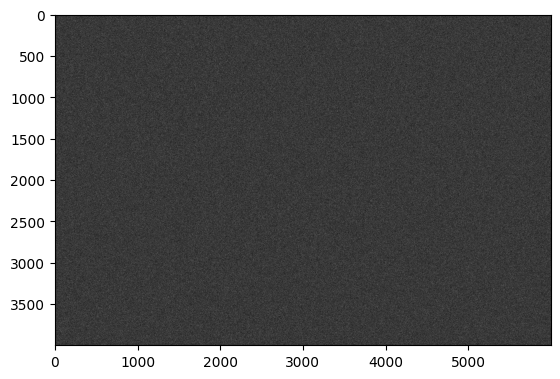

In [5]:
plt.imshow(noise_gauss, cmap="gray")

In [6]:
image2_noise_gauss = cv2.add(image2_gray,noise_gauss)

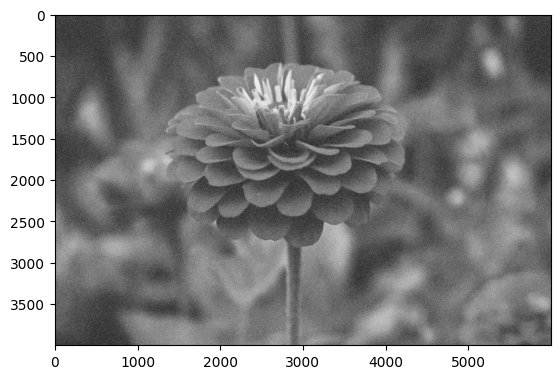

In [7]:
plt.imshow(image2_noise_gauss, cmap="gray")

In [8]:
const_noise = np.zeros(image2_gray.shape, np.int16)
cv2.randu(const_noise, 50, 50) 

array([[50, 50, 50, ..., 50, 50, 50],
       [50, 50, 50, ..., 50, 50, 50],
       [50, 50, 50, ..., 50, 50, 50],
       ...,
       [50, 50, 50, ..., 50, 50, 50],
       [50, 50, 50, ..., 50, 50, 50],
       [50, 50, 50, ..., 50, 50, 50]], shape=(4000, 6000), dtype=int16)

In [10]:
image2_const_noisy = cv2.add(image2_gray.astype(np.int16), const_noise)
image2_const_noisy = np.clip(image2_const_noisy, 0, 255).astype(np.uint8)

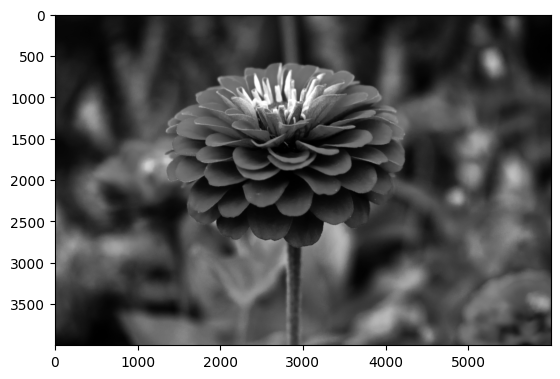

In [11]:
plt.imshow(image2_const_noisy, cmap="gray")


=== Результаты для Гауссовский ===
median    | MSE=1865.38, SSIM=0.0776
gauss     | MSE=3222.96, SSIM=0.1395
bilateral | MSE=4362.51, SSIM=0.0388
nlm       | MSE=7778.20, SSIM=0.0161
gauss (SSIM=0.1395)


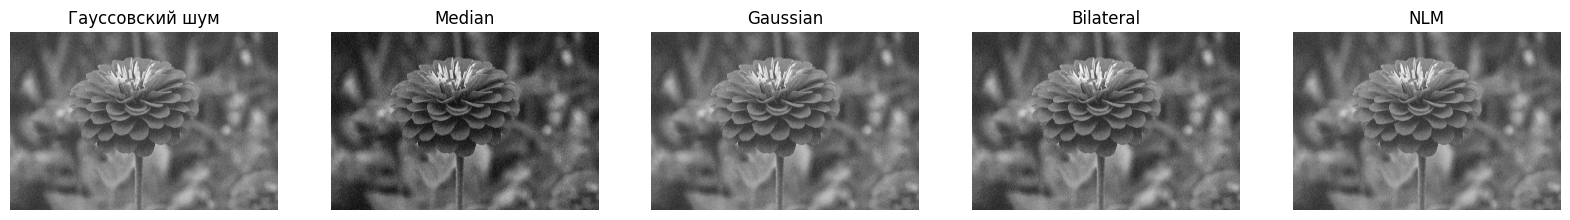


=== Результаты для Постоянный ===
median    | MSE=2499.03, SSIM=0.6668
gauss     | MSE=2505.80, SSIM=0.6700
bilateral | MSE=2510.66, SSIM=0.6206
nlm       | MSE=2509.94, SSIM=0.6184
gauss (SSIM=0.6700)


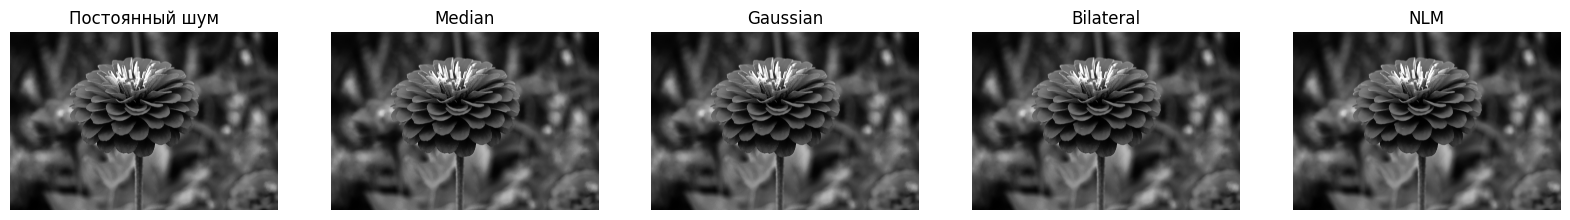

In [13]:
from skimage.metrics import structural_similarity, mean_squared_error

def test_filters(noisy, name=""):
    results = {}

   
    median = cv2.medianBlur(noisy, 3)
    results["median"] = (median, mean_squared_error(image2_gray, median),
                         structural_similarity(image2_gray, median))

    
    gauss = cv2.GaussianBlur(noisy, (5,5), 1)
    results["gauss"] = (gauss, mean_squared_error(image2_gray, gauss),
                        structural_similarity(image2_gray, gauss))

   
    bilateral = cv2.bilateralFilter(noisy, 9, 75, 75)
    results["bilateral"] = (bilateral, mean_squared_error(image2_gray, bilateral),
                            structural_similarity(image2_gray, bilateral))

    
    nlm = cv2.fastNlMeansDenoising(noisy, h=15)
    results["nlm"] = (nlm, mean_squared_error(image2_gray, nlm),
                      structural_similarity(image2_gray, nlm))

    
    print(f"\n=== Результаты для {name} ===")
    best = None
    for k, (img_filt, mse, ssim) in results.items():
        print(f"{k:9s} | MSE={mse:.2f}, SSIM={ssim:.4f}")
        if best is None or ssim > best[2]:
            best = (k, mse, ssim)

    print(f"{best[0]} (SSIM={best[2]:.4f})")

    
    fig, axs = plt.subplots(1, 5, figsize=(20,15))
    axs[0].imshow(noisy, cmap="gray"); axs[0].set_title(f"{name} шум")
    axs[1].imshow(results["median"][0], cmap="gray"); axs[1].set_title("Median")
    axs[2].imshow(results["gauss"][0], cmap="gray"); axs[2].set_title("Gaussian")
    axs[3].imshow(results["bilateral"][0], cmap="gray"); axs[3].set_title("Bilateral")
    axs[4].imshow(results["nlm"][0], cmap="gray"); axs[4].set_title("NLM")
    for ax in axs: ax.axis("off")
    plt.show()


test_filters(image2_noise_gauss, "Гауссовский")
test_filters(image2_const_noisy, "Постоянный")